# 04 — Modélisation Credit Risk
**Objectif :** entraîner un modèle qui prédit la probabilité de défaut à partir des variables d'origination.

**Approche :**
1. **Baseline** : régression logistique (modèle interprétable, référence métier)
2. **Challenger** : XGBoost (gradient boosting, état de l'art sur données tabulaires)
3. Évaluation : AUC, précision/rappel, courbes ROC et PR
4. Gestion du déséquilibre de classes (5.57% de défaut)

**Sortie :** modèle XGBoost sauvegardé pour les notebooks 05 (SHAP) et 06 (RAG).

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
import xgboost as xgb

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR = os.path.join('..', 'data')
X_train_full = pd.read_parquet(os.path.join(DATA_DIR, 'X_train.parquet'))
X_test = pd.read_parquet(os.path.join(DATA_DIR, 'X_test.parquet'))
y_train_full = pd.read_parquet(os.path.join(DATA_DIR, 'y_train.parquet'))['default']
y_test = pd.read_parquet(os.path.join(DATA_DIR, 'y_test.parquet'))['default']

# Split train_full → train (64K) + val (16K) pour l'early stopping
# Le test reste intact pour l'évaluation finale (pas de leakage)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, stratify=y_train_full, random_state=42
)

print(f"Train : {X_train.shape}  | défaut = {y_train.mean():.2%}")
print(f"Val   : {X_val.shape}  | défaut = {y_val.mean():.2%}")
print(f"Test  : {X_test.shape}  | défaut = {y_test.mean():.2%}")

Train : (64000, 39)  | défaut = 5.57%
Val   : (16000, 39)  | défaut = 5.58%
Test  : (20000, 39)  | défaut = 5.57%


## 1. Baseline : régression logistique

Modèle linéaire interprétable. Sert de plancher de performance.
Le scaling est obligatoire (sinon les variables à grande échelle dominent la fonction de coût).

In [2]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # corrige le déséquilibre (5.57% de défaut)
    random_state=42,
    n_jobs=-1,
)
logreg.fit(X_train_scaled, y_train)

proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, proba_lr)
ap_lr = average_precision_score(y_test, proba_lr)
print(f"Logistic Regression — AUC ROC : {auc_lr:.4f} | AP : {ap_lr:.4f}")

Logistic Regression — AUC ROC : 0.7400 | AP : 0.1464


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## 2. XGBoost : modèle challenger

**Méthodologie corrigée :**
- Early stopping sur le **val set** (pas le test → plus de leakage)
- `scale_pos_weight=1` neutralisé : pour les gradient boosting, sur-pondérer la classe minoritaire dégrade souvent l'AUC. On garde l'ordre de probabilités correct.
- `eval_metric='aucpr'` : mieux adapté que `auc` sur des données déséquilibrées
- Profondeur modérée (4) + plus d'arbres (1000) + early stopping → laisse le modèle trouver son optimum
- Régularisation `reg_lambda=1, reg_alpha=0` (L2 par défaut)

In [3]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=10,        # évite des splits sur peu d'observations
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=1,         # neutralisé : la calibration probabiliste est meilleure
    eval_metric='aucpr',        # AP est plus discriminante sur dataset déséquilibré
    early_stopping_rounds=50,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100,
)

# Évaluation sur le TEST set (jamais vu pendant l'entraînement)
proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, proba_xgb)
ap_xgb = average_precision_score(y_test, proba_xgb)

print(f"\nXGBoost — Test AUC : {auc_xgb:.4f} | AP : {ap_xgb:.4f}")
print(f"Best iteration : {xgb_model.best_iteration}")
print(f"\nComparaison :")
print(f"  Logistic Regression  AUC = {auc_lr:.4f}")
print(f"  XGBoost              AUC = {auc_xgb:.4f}  (Δ = {auc_xgb-auc_lr:+.4f})")

[0]	validation_0-aucpr:0.14517	validation_1-aucpr:0.11926
[100]	validation_0-aucpr:0.20522	validation_1-aucpr:0.14894
[193]	validation_0-aucpr:0.22792	validation_1-aucpr:0.14870

XGBoost — Test AUC : 0.7351 | AP : 0.1420
Best iteration : 143

Comparaison :
  Logistic Regression  AUC = 0.7400
  XGBoost              AUC = 0.7351  (Δ = -0.0049)


## 3. Comparaison ROC et Precision-Recall

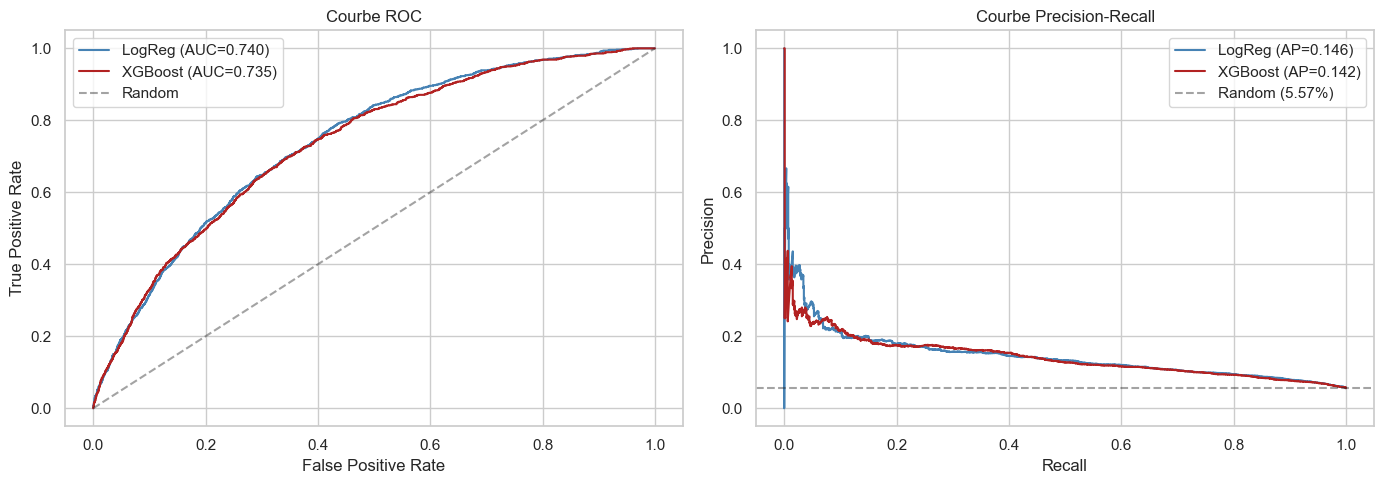

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_xgb)
axes[0].plot(fpr_lr, tpr_lr, label=f'LogReg (AUC={auc_lr:.3f})', color='steelblue')
axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})', color='firebrick')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Courbe ROC')
axes[0].legend()

# Precision-Recall
prec_lr, rec_lr, _ = precision_recall_curve(y_test, proba_lr)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, proba_xgb)
axes[1].plot(rec_lr, prec_lr, label=f'LogReg (AP={ap_lr:.3f})', color='steelblue')
axes[1].plot(rec_xgb, prec_xgb, label=f'XGBoost (AP={ap_xgb:.3f})', color='firebrick')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4,
                label=f'Random ({y_test.mean():.2%})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Matrice de confusion à seuil optimal

On choisit le seuil qui maximise le **F1-score** (compromis précision/rappel).
En crédit, on peut aussi viser un seuil métier (ex. capter 80% des défauts → ajuster en conséquence).

Seuil optimal (max F1) : 0.112
  Précision : 0.161
  Rappel    : 0.369
  F1        : 0.224


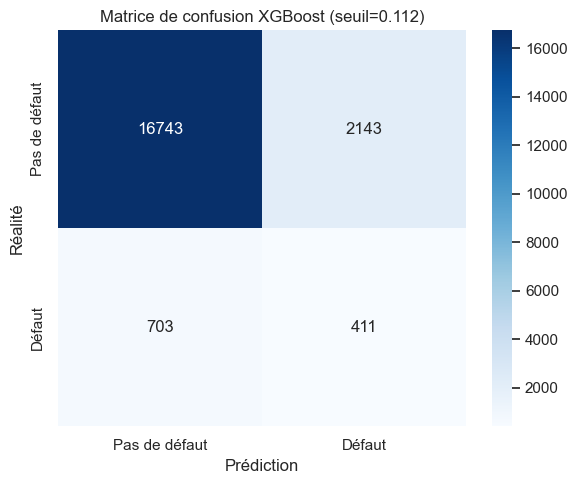


Rapport de classification :
               precision    recall  f1-score   support

Pas de défaut       0.96      0.89      0.92     18886
       Défaut       0.16      0.37      0.22      1114

     accuracy                           0.86     20000
    macro avg       0.56      0.63      0.57     20000
 weighted avg       0.92      0.86      0.88     20000



In [5]:
prec, rec, thresh = precision_recall_curve(y_test, proba_xgb)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1[:-1])
best_thresh = thresh[best_idx]
print(f"Seuil optimal (max F1) : {best_thresh:.3f}")
print(f"  Précision : {prec[best_idx]:.3f}")
print(f"  Rappel    : {rec[best_idx]:.3f}")
print(f"  F1        : {f1[best_idx]:.3f}")

y_pred_xgb = (proba_xgb >= best_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pas de défaut', 'Défaut'],
            yticklabels=['Pas de défaut', 'Défaut'], ax=ax)
ax.set_xlabel('Prédiction')
ax.set_ylabel('Réalité')
ax.set_title(f'Matrice de confusion XGBoost (seuil={best_thresh:.3f})')
plt.tight_layout()
plt.show()

print("\nRapport de classification :")
print(classification_report(y_test, y_pred_xgb, target_names=['Pas de défaut', 'Défaut']))

## 5. Importance des variables (XGBoost natif)

Métrique `gain` : amélioration moyenne de la fonction de perte apportée par chaque feature.
Plus interprétable que `weight` (nombre de splits) qui favorise les variables continues.

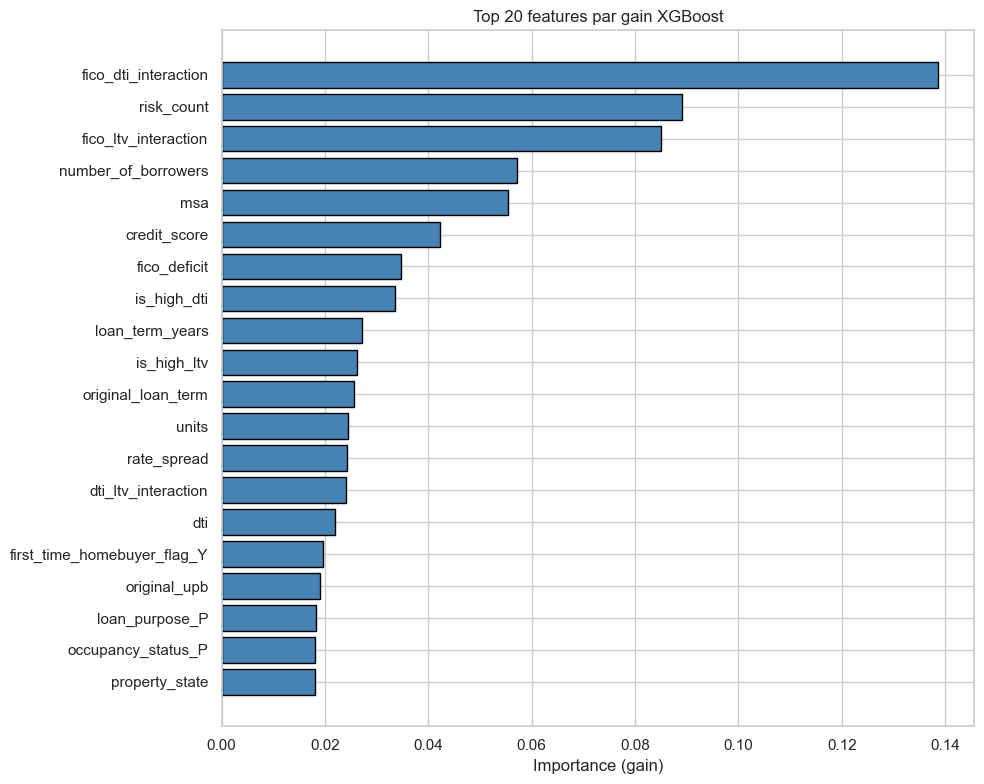


Top 10 features :
             feature     gain
fico_dti_interaction 0.138668
          risk_count 0.089143
fico_ltv_interaction 0.084960
 number_of_borrowers 0.057147
                 msa 0.055377
        credit_score 0.042192
        fico_deficit 0.034673
         is_high_dti 0.033518
     loan_term_years 0.027144
         is_high_ltv 0.026196


In [6]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'gain': xgb_model.feature_importances_,
}).sort_values('gain', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top = importance.head(20)
ax.barh(top['feature'][::-1], top['gain'][::-1], color='steelblue', edgecolor='black')
ax.set_xlabel('Importance (gain)')
ax.set_title('Top 20 features par gain XGBoost')
plt.tight_layout()
plt.show()

print("\nTop 10 features :")
print(importance.head(10).to_string(index=False))

## 6. Distribution des probabilités prédites

Permet de voir si le modèle sépare bien les deux populations.

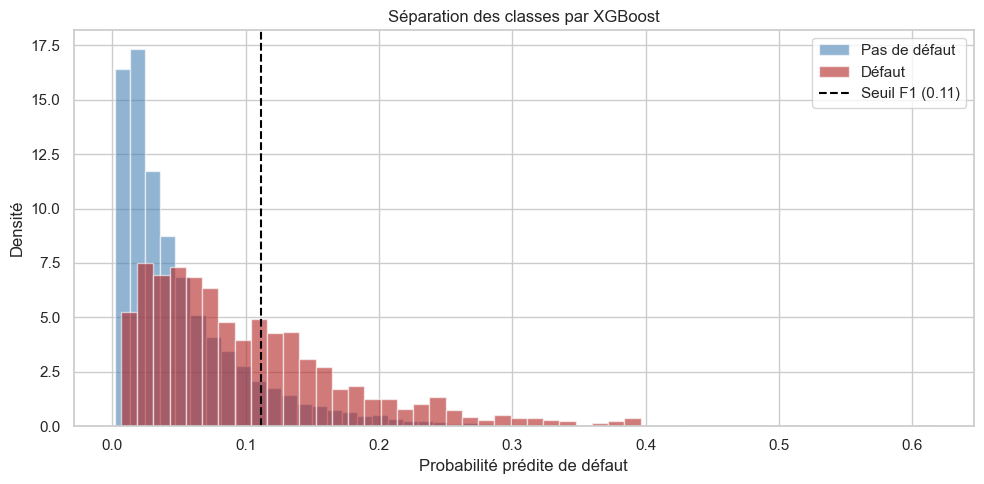

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(proba_xgb[y_test == 0], bins=50, alpha=0.6, label='Pas de défaut', color='steelblue', density=True)
ax.hist(proba_xgb[y_test == 1], bins=50, alpha=0.6, label='Défaut', color='firebrick', density=True)
ax.axvline(best_thresh, color='black', linestyle='--', label=f'Seuil F1 ({best_thresh:.2f})')
ax.set_xlabel('Probabilité prédite de défaut')
ax.set_ylabel('Densité')
ax.set_title('Séparation des classes par XGBoost')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Sauvegarde du modèle et des prédictions

On sauvegarde tout ce dont les notebooks suivants ont besoin :
- Le modèle XGBoost (pour le notebook 05 SHAP et l'app Streamlit)
- Le scaler (la LogReg en aura besoin si on l'inclut dans l'app)
- Les prédictions sur le test (pour les analyses ultérieures)

In [8]:
MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

xgb_model.save_model(os.path.join(MODELS_DIR, 'xgb_credit_risk.json'))
with open(os.path.join(MODELS_DIR, 'logreg.pkl'), 'wb') as f:
    pickle.dump({'model': logreg, 'scaler': scaler}, f)

metadata = {
    'features': list(X_train.columns),
    'auc_xgb': float(auc_xgb),
    'auc_logreg': float(auc_lr),
    'ap_xgb': float(ap_xgb),
    'best_threshold': float(best_thresh),
    'n_train': int(X_train.shape[0]),
    'n_test': int(X_test.shape[0]),
    'default_rate': float(y_train.mean()),
}
with open(os.path.join(MODELS_DIR, 'metadata.pkl'), 'wb') as f:
    pickle.dump(metadata, f)

# Prédictions sur le test
predictions = pd.DataFrame({
    'y_true': y_test.values,
    'proba_xgb': proba_xgb,
    'proba_lr': proba_lr,
})
predictions.to_parquet(os.path.join(DATA_DIR, 'predictions_test.parquet'), index=False)

print("Sauvegardé :")
print(f"  models/xgb_credit_risk.json")
print(f"  models/logreg.pkl")
print(f"  models/metadata.pkl")
print(f"  data/predictions_test.parquet")
print(f"\nRésultats finaux :")
print(f"  Logistic Regression  AUC = {auc_lr:.4f}")
print(f"  XGBoost              AUC = {auc_xgb:.4f}  (Δ = +{auc_xgb-auc_lr:.4f})")

Sauvegardé :
  models/xgb_credit_risk.json
  models/logreg.pkl
  models/metadata.pkl
  data/predictions_test.parquet

Résultats finaux :
  Logistic Regression  AUC = 0.7400
  XGBoost              AUC = 0.7351  (Δ = +-0.0049)
